In [1]:
using JLD2, LaTeXStrings, PGFPlotsX, FileIO, Plots, ColorSchemes

In [2]:
function theoretical_fidelity_limit(α)
    β = sqrt(1 - α^2)
    fidelity_limit = α^4 + β ^4
    return sqrt(fidelity_limit)
end

function single_particle_evolution_fidelity(α, γ_dephase, t)
    β = sqrt(1-α^2)
    fidelity = α^4 + β^4 + (2 * α^2 * β^2 * (exp(-γ_dephase*t)) )
    return sqrt(fidelity)
end

single_particle_evolution_fidelity (generic function with 1 method)

In [7]:
using Random, StatsBase, Statistics

function mean_ci_boot(x; B=10000, level=0.95, seed=42)
    rng = MersenneTwister(seed)
    N = length(x); μ = mean(x)
    means = Vector{Float64}(undef, B)
    @inbounds for b in 1:B
        idx = sample(rng, 1:N, N; replace=true)
        means[b] = mean(@view x[idx])
    end
    α = 1 - level
    return (μ=μ, ci=(quantile(means, α/2), quantile(means, 1-α/2)))
end


mean_ci_boot (generic function with 1 method)

### dephase 1e-5

In [4]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s1.jld2"
e1 = avg_fidelity_after_encoding   
s1 = avg_fidelity_after_storage
c1 = avg_fidelity_after_correction
f1 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s10.jld2"
e10 = avg_fidelity_after_encoding   
s10 = avg_fidelity_after_storage
c10 = avg_fidelity_after_correction
f10 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s20.jld2"
e20 = avg_fidelity_after_encoding   
s20 = avg_fidelity_after_storage
c20 = avg_fidelity_after_correction
f20 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s30.jld2"
e30 = avg_fidelity_after_encoding   
s30 = avg_fidelity_after_storage
c30 = avg_fidelity_after_correction
f30 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s40.jld2"
e40 = avg_fidelity_after_encoding   
s40 = avg_fidelity_after_storage
c40 = avg_fidelity_after_correction
f40 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s50.jld2"
e50 = avg_fidelity_after_encoding   
s50 = avg_fidelity_after_storage
c50 = avg_fidelity_after_correction
f50 = fid_after_correct

e_s = [e1, e10, e20, e30, e40, e50]
s_s = [s1, s10, s20, s30, s40, s50]
c_s = [c1, c10, c20, c30, c40, c50];


In [5]:
idx = [1,10,20,30,40,50]
single_particle = zeros(Float64, length(idx))
for i in 1:length(idx)
    single_particle[i] = single_particle_evolution_fidelity(sqrt(1/5),1.0e-5,(idx[i]+1)*268)
end

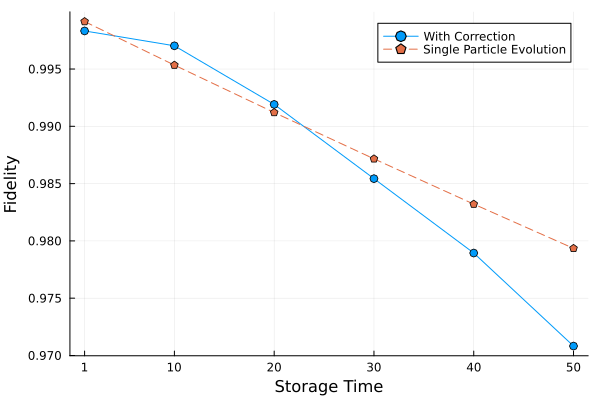

In [6]:
# plot(idx, e_s, label="Encoding", marker=:o)
# plot!(idx, s_s, label="Storage", marker=:o)
plot(idx, c_s, xticks=idx, label="With Correction", marker=:o, 
            ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

In [8]:
bootstrap_f1 = mean_ci_boot(f1)
bootstrap_f10 = mean_ci_boot(f10)
bootstrap_f20 = mean_ci_boot(f20)
bootstrap_f30 = mean_ci_boot(f30)
bootstrap_f40 = mean_ci_boot(f40)
bootstrap_f50 = mean_ci_boot(f50)
bootstrap_distr = [bootstrap_f1, bootstrap_f10, bootstrap_f20, bootstrap_f30, bootstrap_f40, bootstrap_f50]

6-element Vector{@NamedTuple{μ::Float64, ci::Tuple{Float64, Float64}}}:
 (μ = 0.9983244865501146, ci = (0.9977066600192578, 0.9988640481754559))
 (μ = 0.9970267921778242, ci = (0.9961537866353154, 0.9978195816553814))
 (μ = 0.9919109546845551, ci = (0.990380622023363, 0.9933656396635173))
 (μ = 0.9854302316659446, ci = (0.983410509397772, 0.9873952512071407))
 (μ = 0.9789385352668291, ci = (0.9764430106539648, 0.9813384585856044))
 (μ = 0.9708186656697653, ci = (0.9678930693872722, 0.9736135620867563))

In [9]:
y_err = [bootstrap_distr[i].ci for i in 1:length(bootstrap_distr)];

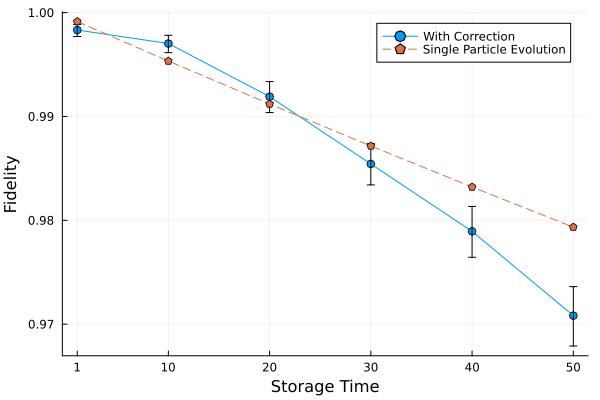

In [10]:
lo = first.(y_err)
hi = last.(y_err)
yerr = (c_s .- lo, hi .- c_s)
plot(idx, c_s, xticks=idx, yerr=yerr,
    label="With Correction", marker=:o, 
    ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

In [16]:
# lo = first.(y_err)
# hi = last.(y_err)
# yerr = (c_s .- lo, hi .- c_s)
# plot(idx, 1 .- c_s, xticks=idx, yerr=yerr,
#     label="With Correction", marker=:o, 
#     ylabel="Infidelity", xlabel="Storage Time", grid=true)
# plot!(idx, 1 .- single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

In [18]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_50k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=50000_avg_s6.jld2"
e6 = avg_fidelity_after_encoding
s6 = avg_fidelity_after_storage
c6 = avg_fidelity_after_correction
f6 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_50k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=50000_avg_s12.jld2"
e12 = avg_fidelity_after_encoding
s12 = avg_fidelity_after_storage
c12 = avg_fidelity_after_correction
f12 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_50k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=50000_avg_s18.jld2"
e18 = avg_fidelity_after_encoding
s18 = avg_fidelity_after_storage
c18 = avg_fidelity_after_correction
f18 = fid_after_correct

e_50k = [e6, e10, e12, e18]
s_50k = [s6, s10, s12, s18]
c_50k = [c6, c10, c12, c18];

idx_50k = [6,10,12,18]
single_particle_50k = zeros(Float64, length(idx_50k))
for i in 1:length(idx_50k)
    single_particle_50k[i] = single_particle_evolution_fidelity(sqrt(1/5),1.0e-5,(idx_50k[i]+1)*268)
end


bootstrap_f6 = mean_ci_boot(f6)
bootstrap_f12 = mean_ci_boot(f12)
bootstrap_f18 = mean_ci_boot(f18)
bootstrap_distr_50k = [bootstrap_f6, bootstrap_f10, bootstrap_f12, bootstrap_f18]
y_err_50k = [bootstrap_distr_50k[i].ci for i in 1:length(bootstrap_distr_50k)];

lo_50k = first.(y_err_50k)
hi_50k = last.(y_err_50k)
yerr_50k = (c_50k .- lo_50k, hi_50k .- c_50k)

([0.0003269996081728399, 0.0008732590270228435, 0.0004299335338360244, 0.0005823997031741968], [0.00032564474416529876, 0.0007925359930431863, 0.0004254600922856122, 0.0005732760263529313])

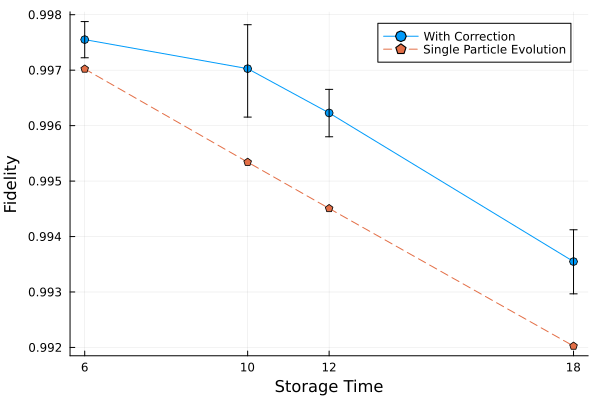

In [17]:
plot(idx_50k, c_50k, xticks=idx_50k, yerr=yerr_50k,
    label="With Correction", marker=:o, 
    ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx_50k, single_particle_50k, label="Single Particle Evolution", marker=:p, linestyle=:dash)

### dephase 1e-4

In [29]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s1.jld2"
e1 = avg_fidelity_after_encoding   
s1 = avg_fidelity_after_storage
c1 = avg_fidelity_after_correction
f1 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s10.jld2"
e10 = avg_fidelity_after_encoding   
s10 = avg_fidelity_after_storage
c10 = avg_fidelity_after_correction
f10 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s20.jld2"
e20 = avg_fidelity_after_encoding   
s20 = avg_fidelity_after_storage
c20 = avg_fidelity_after_correction
f20 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s30.jld2"
e30 = avg_fidelity_after_encoding   
s30 = avg_fidelity_after_storage
c30 = avg_fidelity_after_correction
f30 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s40.jld2"
e40 = avg_fidelity_after_encoding   
s40 = avg_fidelity_after_storage
c40 = avg_fidelity_after_correction
f40 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.0001_case1_phase=0.915_Ntraj=10000_avg_s50.jld2"
e50 = avg_fidelity_after_encoding   
s50 = avg_fidelity_after_storage
c50 = avg_fidelity_after_correction
f50 = fid_after_correct

e_s = [e1, e10, e20, e30, e40, e50]
s_s = [s1, s10, s20, s30, s40, s50]
c_s = [c1, c10, c20, c30, c40, c50];


In [30]:
idx = [1,10,20,30,40,50]
single_particle = zeros(Float64, length(idx))
for i in 1:length(idx)
    single_particle[i] = single_particle_evolution_fidelity(sqrt(1/5),0.0001,(idx[i]+1)*268)
end

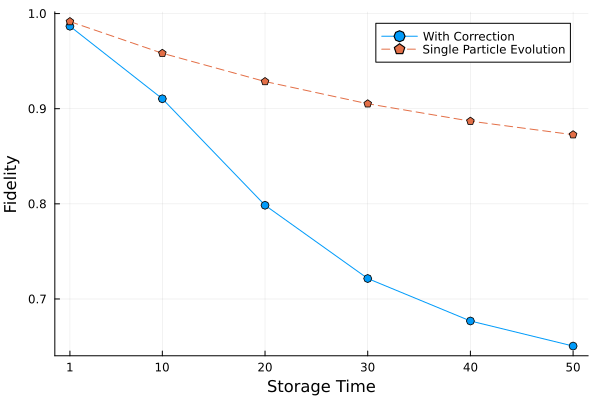

In [31]:
# plot(idx, e_s, label="Encoding", marker=:o)
# plot!(idx, s_s, label="Storage", marker=:o)
plot(idx, c_s, xticks=idx, label="With Correction", marker=:o, 
            ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

In [32]:
bootstrap_f1 = mean_ci_boot(f1)
bootstrap_f10 = mean_ci_boot(f10)
bootstrap_f20 = mean_ci_boot(f20)
bootstrap_f30 = mean_ci_boot(f30)
bootstrap_f40 = mean_ci_boot(f40)
bootstrap_f50 = mean_ci_boot(f50)
bootstrap_distr = [bootstrap_f1, bootstrap_f10, bootstrap_f20, bootstrap_f30, bootstrap_f40, bootstrap_f50]

6-element Vector{@NamedTuple{μ::Float64, ci::Tuple{Float64, Float64}}}:
 (μ = 0.9866771672039755, ci = (0.9847174519922295, 0.9885611471951578))
 (μ = 0.9104341569980957, ci = (0.9055880808774325, 0.9151990885999939))
 (μ = 0.7985650072395738, ci = (0.7919299261507301, 0.8050944850954237))
 (μ = 0.7214708245594061, ci = (0.7142505137837113, 0.7286709033752287))
 (μ = 0.6769198311418267, ci = (0.6694767631122037, 0.6843491888873674))
 (μ = 0.6505679151618127, ci = (0.6430729421136999, 0.6580365028230613))

In [33]:
y_err = [bootstrap_distr[i].ci for i in 1:length(bootstrap_distr)];

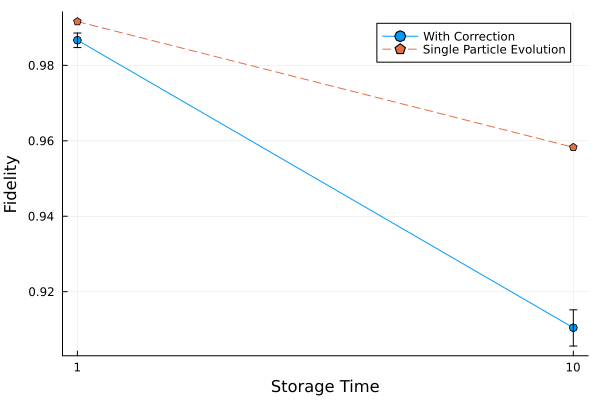

In [36]:
lo = first.(y_err)
hi = last.(y_err)
yerr = (c_s .- lo, hi .- c_s)
plot(idx[1:2], c_s[1:2], xticks=idx, yerr=yerr,
    label="With Correction", marker=:o, 
    ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx[1:2], single_particle[1:2], label="Single Particle Evolution", marker=:p, linestyle=:dash)

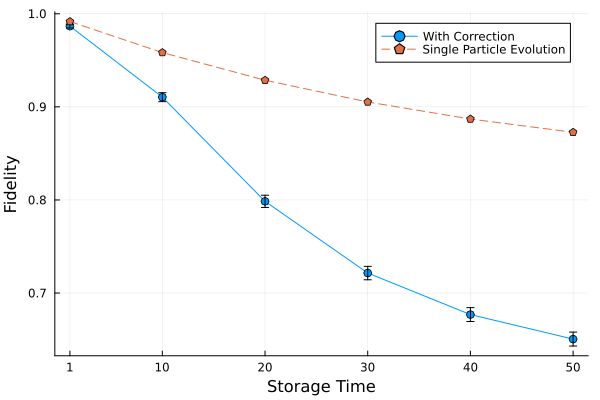

In [35]:
lo = first.(y_err)
hi = last.(y_err)
yerr = (c_s .- lo, hi .- c_s)
plot(idx, c_s, xticks=idx, yerr=yerr,
    label="With Correction", marker=:o, 
    ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

### dephase 1e-3

In [16]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s1.jld2"
e1 = avg_fidelity_after_encoding   
s1 = avg_fidelity_after_storage
c1 = avg_fidelity_after_correction
f1 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s10.jld2"
e10 = avg_fidelity_after_encoding   
s10 = avg_fidelity_after_storage
c10 = avg_fidelity_after_correction
f10 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s20.jld2"
e20 = avg_fidelity_after_encoding   
s20 = avg_fidelity_after_storage
c20 = avg_fidelity_after_correction
f20 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s30.jld2"
e30 = avg_fidelity_after_encoding   
s30 = avg_fidelity_after_storage
c30 = avg_fidelity_after_correction
f30 = fid_after_correct


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s40.jld2"
e40 = avg_fidelity_after_encoding   
s40 = avg_fidelity_after_storage
c40 = avg_fidelity_after_correction
f40 = fid_after_correct

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=0.001_case1_phase=0.915_Ntraj=10000_avg_s50.jld2"
e50 = avg_fidelity_after_encoding   
s50 = avg_fidelity_after_storage
c50 = avg_fidelity_after_correction
f50 = fid_after_correct;

e_s = [e1, e10, e20, e30, e40, e50]
s_s = [s1, s10, s20, s30, s40, s50]
c_s = [c1, c10, c20, c30, c40, c50];


In [17]:
idx = [1,10,20,30,40,50]
single_particle = zeros(Float64, length(idx))
for i in 1:length(idx)
    single_particle[i] = single_particle_evolution_fidelity(sqrt(1/5),0.001,(idx[i]+1)*268)
end

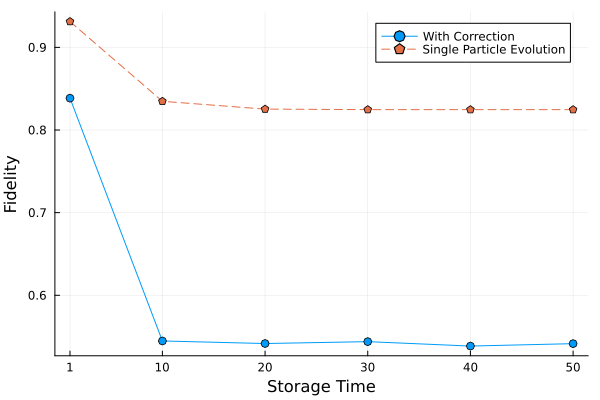

In [18]:
# plot(idx, e_s, label="Encoding", marker=:o)
# plot!(idx, s_s, label="Storage", marker=:o)
plot(idx, c_s, xticks=idx, label="With Correction", marker=:o, 
            ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)

In [19]:
bootstrap_f1 = mean_ci_boot(f1)
bootstrap_f10 = mean_ci_boot(f10)
bootstrap_f20 = mean_ci_boot(f20)
bootstrap_f30 = mean_ci_boot(f30)
bootstrap_f40 = mean_ci_boot(f40)
bootstrap_f50 = mean_ci_boot(f50)
bootstrap_distr = [bootstrap_f1, bootstrap_f10, bootstrap_f20, bootstrap_f30, bootstrap_f40, bootstrap_f50]

6-element Vector{@NamedTuple{μ::Float64, ci::Tuple{Float64, Float64}}}:
 (μ = 0.8385214409744508, ci = (0.8324635314171432, 0.844613896043795))
 (μ = 0.5447631788295526, ci = (0.5372338004163614, 0.5524295303081427))
 (μ = 0.5416549738224429, ci = (0.534084007215649, 0.5492171343311205))
 (μ = 0.5438667269113089, ci = (0.5362473556626834, 0.551508702869134))
 (μ = 0.5385153485305181, ci = (0.530929307987962, 0.546131911972245))
 (μ = 0.5415115270943168, ci = (0.5339007384464587, 0.5491008799426416))

In [20]:
y_err = [bootstrap_distr[i].ci for i in 1:length(bootstrap_distr)];

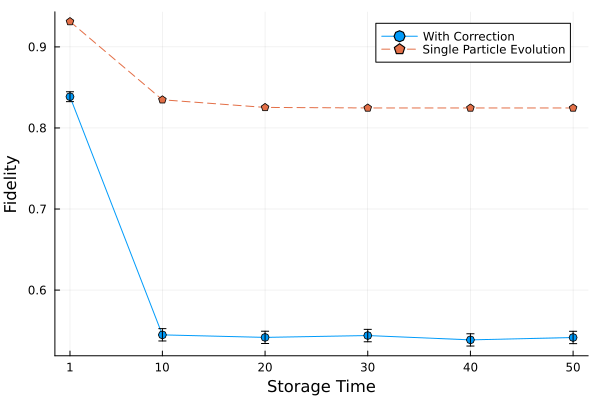

In [21]:
lo = first.(y_err)
hi = last.(y_err)
yerr = (c_s .- lo, hi .- c_s)
plot(idx, c_s, xticks=idx, yerr=yerr,
    label="With Correction", marker=:o, 
    ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)